In [1]:
import os
import sys
import matplotlib.pyplot as plt
from matplotlib.pylab import mpl
import numpy as np
import pandas as pd
import pickle
import copy
from data_evaluation_API import data_evaluation as eval
from Influxdb_API.Influxdb_API import ClientInfluxdb
%matplotlib inline

# 1. 以单组数据为例
### 1.1 从Influxdb_API获取数据
以1K0V多联机0号室内机的温度数据为例  

In [2]:
db_name='moserver'
params={
    'measurement_name':'modata',
    'start_time': pd.to_datetime('2022-07-01 00:00:00'),
    'end_time': pd.to_datetime('2022-09-01 00:00:00'),
    'field_list': ['roomTemp'],
    'tag_dict': {'nid': 'vrf/vrf_0000CC311178CCM26232341000271K0V/indoor/0'},
    'fore': False,
    'fore_horizon': None,
    'interval': None
}
db_client = ClientInfluxdb(db_name=db_name) 
df = db_client.read_influxdb(**params)
print('data acquired\n')

data acquired



### 1.2 设定相关处理参数，对数据进行必要的前处理
将从数据库中获取的数据的字符类型转换为float类型  
进行重采样

In [3]:
params_process={
    'rsp_time': pd.Timedelta('15 min'),
    'rsp_num': 4, # 4 times per hour
    'step': 4*24*3,  # to calculate missing rate, step=4/h*24h/day*3day表示计算每个时刻向前回溯三天的数据缺失率
    'imputation_time_delta': pd.Timedelta('6 hours') # 连续缺失超过imputation_time_delta的数据将不会被插补
}
# str -> np.float64
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')
# resampling data, rsp_time=15min
df = eval.resampling(df, params_process['rsp_time'])
print(df)

                      roomTemp
2022-07-01 00:00:00  30.344444
2022-07-01 00:15:00  30.481818
2022-07-01 00:30:00  30.618182
2022-07-01 00:45:00  30.700000
2022-07-01 01:00:00  30.700000
...                        ...
2022-08-07 09:15:00  31.310000
2022-08-07 09:30:00  31.400000
2022-08-07 09:45:00  31.430000
2022-08-07 10:00:00  31.500000
2022-08-07 10:15:00  31.470000

[3594 rows x 1 columns]


### 1.3 计算原始数据/去除异常值数据/数据插补后的数据缺失率，并输出最优最近的时刻
params_process['step'] = 4/h * 24h/day * 3day 表示计算每个时刻向前回溯三天的数据缺失率

1.3.1 计算原始数据的数据缺失率

roomTemp minimal missing rate:  0.0
roomTemp average missing rate:  0.0986366165831921
roomTemp the closest optimal moment to the present:  2022-08-07 10:15:00 



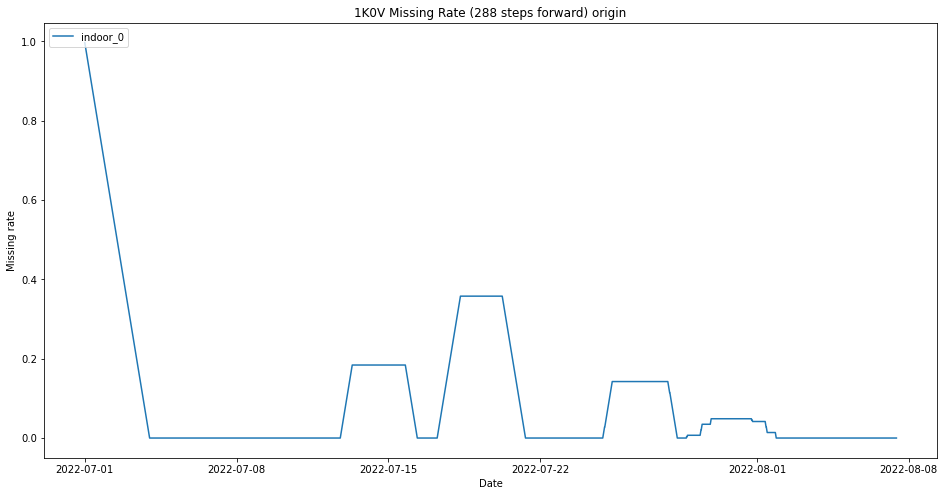

In [4]:
missing_rate = eval.cal_missing_rate(df, params_process['step'])

id = params['tag_dict']['nid'].split('/')[-3][-4:]
label = params['tag_dict']['nid'].split('/')[-2] + '_' + params['tag_dict']['nid'].split('/')[-1]
step = params_process['step']
plt.plot(missing_rate.index, missing_rate, label=label)
plt.title(id + f' Missing Rate ({step} steps forward) ' + 'origin')
plt.xlabel("Date")
plt.ylabel("Missing rate")
plt.legend(loc = 'upper left')
plt.gcf().set_size_inches(16, 8)
plt.show()


1.3.2 计算去除异常值后的数据缺失率

roomTemp minimal missing rate:  0.0
roomTemp average missing rate:  0.0986366165831921
roomTemp the closest optimal moment to the present:  2022-08-07 10:15:00 



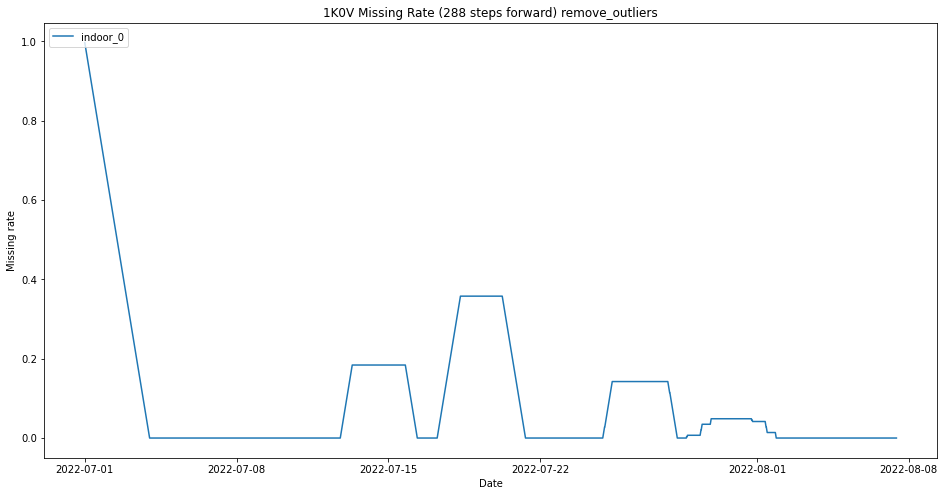

In [5]:
df_process = eval.remove_outliers(df)
missing_rate_process = eval.cal_missing_rate(df_process, params_process['step'])

id = params['tag_dict']['nid'].split('/')[-3][-4:]
label = params['tag_dict']['nid'].split('/')[-2] + '_' + params['tag_dict']['nid'].split('/')[-1]
step = params_process['step']
plt.plot(missing_rate_process.index, missing_rate_process, label=label)
plt.title(id + f' Missing Rate ({step} steps forward) ' + 'remove_outliers')
plt.xlabel("Date")
plt.ylabel("Missing rate")
plt.legend(loc = 'upper left')
plt.gcf().set_size_inches(16, 8)
plt.show()

1.3.3 计算数据插补后的数据缺失率

roomTemp minimal missing rate:  0.0
roomTemp average missing rate:  0.09251530328324853
roomTemp the closest optimal moment to the present:  2022-08-07 10:15:00 



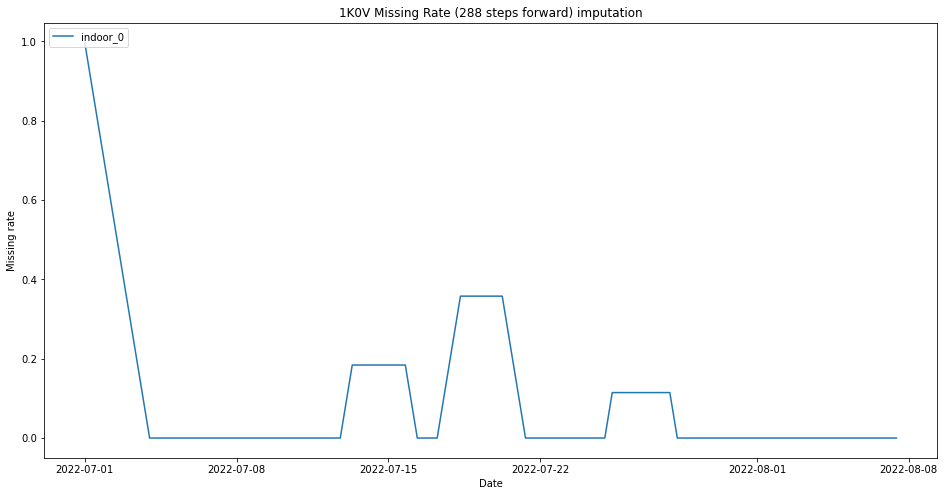

In [6]:
df_new = eval.linear_imputation(df_process, params_process['imputation_time_delta'], params_process['rsp_time'])
missing_rate_new = eval.cal_missing_rate(df_new, params_process['step'])

id = params['tag_dict']['nid'].split('/')[-3][-4:]
label = params['tag_dict']['nid'].split('/')[-2] + '_' + params['tag_dict']['nid'].split('/')[-1]
step = params_process['step']
plt.plot(missing_rate_new.index, missing_rate_new, label=label)
plt.title(id + f' Missing Rate ({step} steps forward) ' + 'imputation')
plt.xlabel("Date")
plt.ylabel("Missing rate")
plt.legend(loc = 'upper left')
plt.gcf().set_size_inches(16, 8)
plt.show()

# 2. 以多组数据为例
### 2.1 从Influxdb_API获取数据
1K0V多联机0号室内机的温度数据与多联机用电数据

In [7]:
db_name1='moserver'
params1={
    'measurement_name':'modata',
    'start_time': pd.to_datetime('2022-07-01 00:00:00'),
    'end_time': pd.to_datetime('2022-09-01 00:00:00'),
    'field_list': ['roomTemp'],
    'tag_dict': {'nid': 'vrf/vrf_0000CC311178CCM26232341000271K0V/indoor/0'},
    'fore': False,
    'fore_horizon': None,
    'interval': None
}
db_client1 = ClientInfluxdb(db_name=db_name1) 
df1 = db_client1.read_influxdb(**params1)
# str -> np.float64
for col in df1.columns:
    df1[col] = pd.to_numeric(df1[col], errors='ignore')
# resampling data, rsp_time=15min
df1 = eval.resampling(df1)

db_name2 = 'moserveribms'
params2 = {
    'measurement_name': 'ibmsV2modata',
    'start_time': pd.to_datetime('2022-07-01 00:00:00'),
    'end_time': pd.to_datetime('2022-09-01 00:00:00'),
    'field_list': ['E'],
    'tag_dict': {'nid': 'ibmsv2/ibmsv2_5929149262402256896/EMeter/mDev_EMeter_Roof_MDV_10'},
    'fore': False,
    'fore_horizon': None,
    'interval': None
}
db_client2 = ClientInfluxdb(db_name=db_name2) 
df2 = db_client2.read_influxdb(**params2)
# str -> np.float64
for col in df2.columns:
    df2[col] = pd.to_numeric(df2[col], errors='ignore')
# resampling data, rsp_time=15min
df2 = eval.resampling(df2)

df = df2.join(df1)
print(df)
print('data acquired\n')

                           E   roomTemp
2022-07-01 00:00:00  1051.71  30.344444
2022-07-01 00:15:00  1051.92  30.481818
2022-07-01 00:30:00  1051.92  30.618182
2022-07-01 00:45:00  1052.11  30.700000
2022-07-01 01:00:00  1052.11  30.700000
...                      ...        ...
2022-08-31 22:45:00  2528.60        NaN
2022-08-31 23:00:00  2528.60        NaN
2022-08-31 23:15:00  2528.60        NaN
2022-08-31 23:30:00  2528.60        NaN
2022-08-31 23:45:00  2528.61        NaN

[5952 rows x 2 columns]
data acquired



### 2.2 计算原始数据/去除异常值数据/数据插补后的数据缺失率，并输出“各组数据最优最近的时刻”和“所有数据满足3天缺失率低于20%的最近时刻”

E minimal missing rate:  0.0
E average missing rate:  0.5083422005674989
E the closest optimal moment to the present:  2022-07-27 13:45:00 

roomTemp minimal missing rate:  0.0
roomTemp average missing rate:  0.4316196236559128
roomTemp the closest optimal moment to the present:  2022-08-07 10:15:00 

The closest moment meets the condition(< 20% missing rate) for multivariables:  2022-07-31 19:45:00 



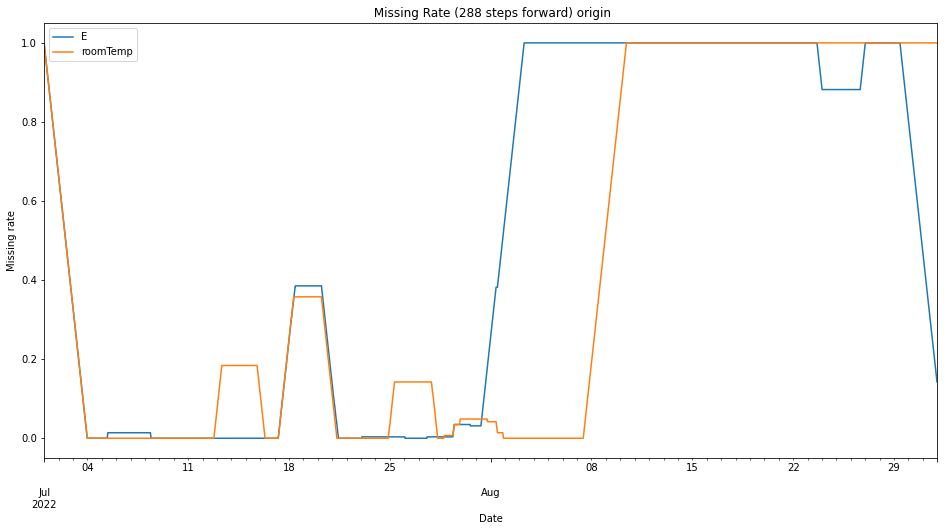

In [8]:
missing_rate = eval.cal_missing_rate(df, params_process['step'])

missing_rate.plot()
plt.title(f' Missing Rate ({step} steps forward) ' + 'origin')
plt.xlabel("Date")
plt.ylabel("Missing rate")
plt.legend(loc = 'upper left')
plt.gcf().set_size_inches(16, 8)
plt.show()

E minimal missing rate:  0.0
E average missing rate:  0.5083422005674989
E the closest optimal moment to the present:  2022-07-27 13:45:00 

roomTemp minimal missing rate:  0.0
roomTemp average missing rate:  0.4316196236559128
roomTemp the closest optimal moment to the present:  2022-08-07 10:15:00 

The closest moment meets the condition(< 20% missing rate) for multivariables:  2022-07-31 19:45:00 



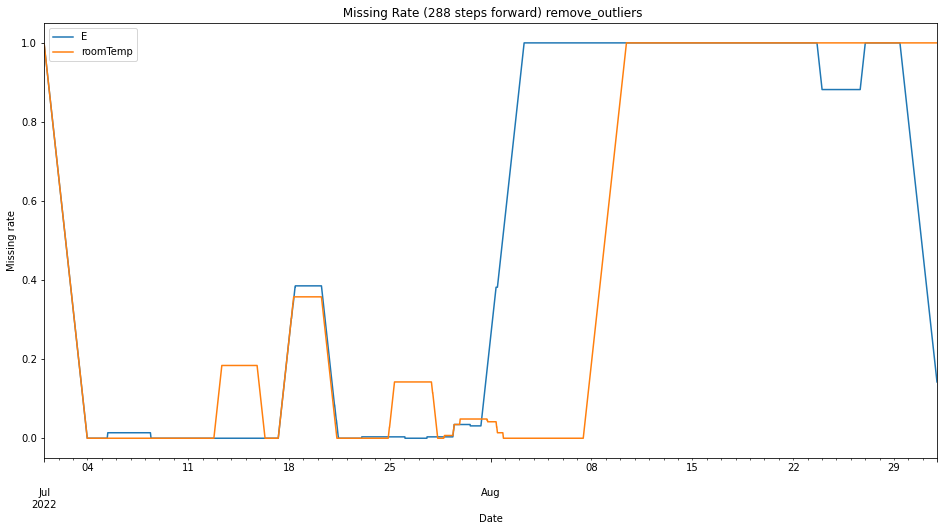

In [9]:
df_process = eval.remove_outliers(df)
missing_rate_process = eval.cal_missing_rate(df_process, params_process['step'])

missing_rate_process.plot()
plt.title(f' Missing Rate ({step} steps forward) ' + 'remove_outliers')
plt.xlabel("Date")
plt.ylabel("Missing rate")
plt.legend(loc = 'upper left')
plt.gcf().set_size_inches(16, 8)
plt.show()

E minimal missing rate:  0.0
E average missing rate:  0.5017897812126604
E the closest optimal moment to the present:  2022-07-31 07:45:00 

roomTemp minimal missing rate:  0.0
roomTemp average missing rate:  0.4279233870967734
roomTemp the closest optimal moment to the present:  2022-08-07 10:15:00 

The closest moment meets the condition(< 20% missing rate) for multivariables:  2022-07-31 22:00:00 



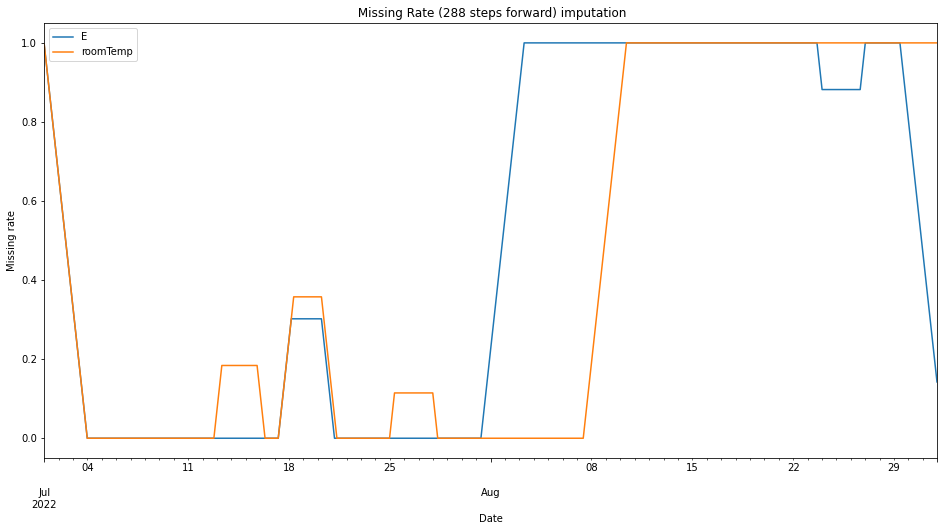

In [10]:
df_new = eval.linear_imputation(df_process, params_process['imputation_time_delta'], params_process['rsp_time'])
missing_rate_new = eval.cal_missing_rate(df_new, params_process['step'])

missing_rate_new.plot()
plt.title(f' Missing Rate ({step} steps forward) ' + 'imputation')
plt.xlabel("Date")
plt.ylabel("Missing rate")
plt.legend(loc = 'upper left')
plt.gcf().set_size_inches(16, 8)
plt.show()